In [40]:
import numpy as np
from scipy.io import loadmat
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.anova import AnovaRM
import os
from dotenv import load_dotenv; load_dotenv()
%cd {os.getenv('PROJECT_PATH')}

/home/id94ebid/projects/neuroscience


In [82]:
# Read .mat files
data_ts = loadmat('data_processed/lsd/time_series_data.mat')
data_names = loadmat('data_processed/lsd/condition_names.mat')
parts = ['Thalamus','Visual_Cortex','Posterior_Cingulate_Cortex', 'Temporal_Gyrus']

data = {str(data_names['conditionNames'][0,i][0]): np.array([data_ts['pyDict'][0,i][part][0,0] for part in parts]).transpose(1,0,2) for i in range(3)}
print(data.keys())
n_subs, n_rois, n_time = data['LSD'].shape  # (number of subjects, number of ROIs, number of time points)

dict_keys(['Placebo', 'LSD', 'LSD+Ketanserin'])


In [42]:
data['LSD'].shape

(25, 4, 240)

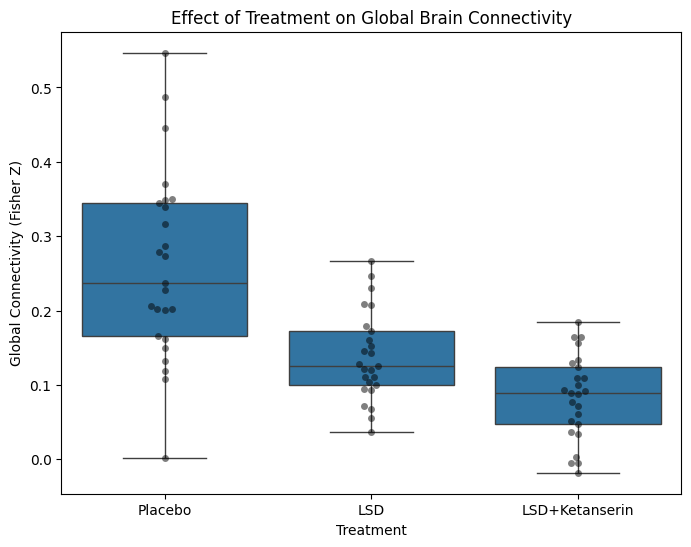

In [43]:

def compute_fc(time_series_data):
    """
    Input: (n_subs, n_rois, n_time)
    Output: (n_subs, n_rois, n_rois) - Fisher Z transformed matrices
    """
    n_s, n_r, n_t = time_series_data.shape
    fc_matrices = []
    
    for sub in range(n_s):
        # Transpose to (Time, ROIs) for corrcoef
        ts = time_series_data[sub, :, :]
        corr = np.corrcoef(ts)
        
        # Fisher Z transform (avoid inf at r=1 by clipping)
        corr = np.clip(corr, -0.999, 0.999)
        z_corr = np.arctanh(corr)
        fc_matrices.append(z_corr)
        
    return np.array(fc_matrices)

# 1. Compute Connectivity
fc_placebo = compute_fc(data['Placebo'])
fc_lsd = compute_fc(data['LSD'])
fc_ket = compute_fc(data['LSD+Ketanserin'])

# 2. Extract Mean Global Connectivity (upper triangle only)
# We mask the diagonal since it is always infinite/1
triu_indices = np.triu_indices(n_rois, k=1)

df_fc = pd.DataFrame({
    'Placebo': [m[triu_indices].mean() for m in fc_placebo],
    'LSD': [m[triu_indices].mean() for m in fc_lsd],
    'LSD+Ketanserin': [m[triu_indices].mean() for m in fc_ket]
})

# Reshape for plotting
df_long = df_fc.melt(var_name='Treatment', value_name='Global Connectivity (Fisher Z)')

# 3. Visualize
plt.figure(figsize=(8, 6))
sns.boxplot(x='Treatment', y='Global Connectivity (Fisher Z)', data=df_long)
sns.swarmplot(x='Treatment', y='Global Connectivity (Fisher Z)', data=df_long, color='black', alpha=0.5)
plt.title("Effect of Treatment on Global Brain Connectivity")
plt.show()

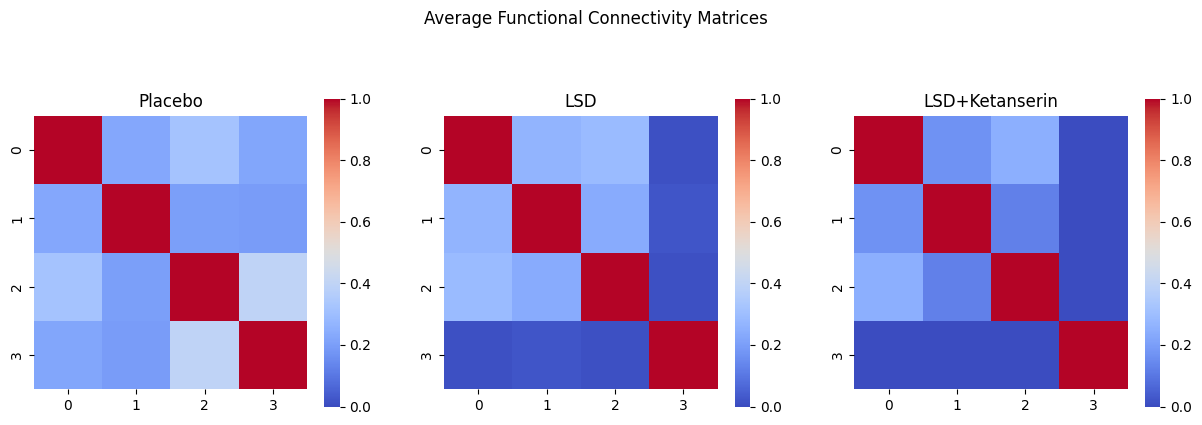

In [44]:
# plot 3 matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['Placebo', 'LSD', 'LSD+Ketanserin']
for ax, fc_matrix, title in zip(axes, [fc_placebo.mean(axis=0), fc_lsd.mean(axis=0), fc_ket.mean(axis=0)], titles):
    sns.heatmap(fc_matrix, ax=ax, vmin=0, vmax=1, cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
    ax.set_title(title)
plt.suptitle("Average Functional Connectivity Matrices")
plt.show()

In [45]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# 1. Prepare Dataframe for Statsmodels
# We need columns: SubjectID, Treatment, Value
records = []
for treatment, matrices in zip(['Placebo', 'LSD', 'LSD+Ketanserin'], [fc_placebo, fc_lsd, fc_ket]):
    for sub_idx, matrix in enumerate(matrices):
        # Taking mean connectivity as the metric
        val = matrix[triu_indices].mean()
        records.append({'Subject': f'S{sub_idx}', 'Treatment': treatment, 'Connectivity': val})

df_stats = pd.DataFrame(records)
df_stats['Treatment'] = pd.Categorical(
    df_stats['Treatment'], 
    categories=['Placebo', 'LSD', 'LSD+Ketanserin'], 
    ordered=False
)

# 2. Now you can use a simpler formula without C()
md = smf.mixedlm("Connectivity ~ Treatment", df_stats, groups=df_stats["Subject"])
mdf = md.fit()
print(mdf.summary())

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Connectivity
No. Observations:     75          Method:                 REML        
No. Groups:           25          Scale:                  0.0050      
Min. group size:      3           Log-Likelihood:         72.6041     
Max. group size:      3           Converged:              Yes         
Mean group size:      3.0                                             
----------------------------------------------------------------------
                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                    0.260    0.017 14.920 0.000  0.226  0.294
Treatment[T.LSD]            -0.122    0.020 -6.133 0.000 -0.161 -0.083
Treatment[T.LSD+Ketanserin] -0.176    0.020 -8.866 0.000 -0.215 -0.137
Group Var                    0.003    0.022                           



/home/id94ebid/projects/neuroscience/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [57]:
import numpy as np
from scipy.signal import welch, detrend
from scipy.integrate import simpson
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import fdrcorrection

# -------------------------
# Spectral features per ROI
# -------------------------
def compute_psd_features_1d(x, fs, band=(0.01, 0.08), total_band=None, nperseg=128):
    """
    x: (T,)
    fs: sampling frequency = 1/TR
    band: band for low-frequency power (ALFF-like)
    total_band: denominator band for fALFF; if None uses (eps, fs/2)
    """
    x = np.asarray(x, dtype=float)
    x = detrend(x, type="linear")

    # Welch PSD
    nperseg = min(nperseg, len(x))
    f, Pxx = welch(x, fs=fs, nperseg=nperseg, scaling="density")

    eps = 1e-12
    lo, hi = band
    idx = (f >= lo) & (f <= hi)
    bandpower = simpson(Pxx[idx], f[idx]) if np.any(idx) else np.nan

    if total_band is None:
        tlo, thi = (eps, fs / 2)
    else:
        tlo, thi = total_band
    tidx = (f >= tlo) & (f <= thi)
    totalpower = simpson(Pxx[tidx], f[tidx]) if np.any(tidx) else np.nan
    falff = bandpower / totalpower if (np.isfinite(totalpower) and totalpower > 0) else np.nan

    peak_f = f[idx][np.argmax(Pxx[idx])] if np.any(idx) else np.nan

    return bandpower, falff, peak_f


def extract_features_for_condition(arr, TR, band=(0.01, 0.08), nperseg=128):
    """
    arr: (S, R, T)
    returns dict of metrics each (S, R)
    """
    arr = np.asarray(arr)
    if arr.ndim != 3:
        raise ValueError(f"Expected (subjects, rois, time); got shape {arr.shape}")

    fs = 1.0 / TR
    S, R, T = arr.shape

    bandpower = np.full((S, R), np.nan, dtype=float)
    falff = np.full((S, R), np.nan, dtype=float)
    peak_f = np.full((S, R), np.nan, dtype=float)

    for s in range(S):
        for r in range(R):
            bp, fa, pf = compute_psd_features_1d(arr[s, r], fs=fs, band=band, nperseg=nperseg)
            bandpower[s, r] = bp
            falff[s, r] = fa
            peak_f[s, r] = pf

    return {"bandpower": bandpower, "falff": falff, "peak_f": peak_f}


def extract_features_dict(data_dict, TR, band=(0.01, 0.08), nperseg=128, conditions=None):
    """
    data_dict: {'Placebo': (S,R,T), 'LSD': ..., 'LSD+Ketanserin': ...}
    returns: features[cond][metric] = (S,R)
    """
    if conditions is None:
        conditions = list(data_dict.keys())

    # basic consistency checks
    shapes = {c: np.asarray(data_dict[c]).shape for c in conditions}
    first = shapes[conditions[0]]
    for c, sh in shapes.items():
        if sh != first:
            raise ValueError(f"All conditions must have same shape. Got {shapes}")

    features = {}
    for c in conditions:
        features[c] = extract_features_for_condition(
            data_dict[c], TR=TR, band=band, nperseg=nperseg
        )
    return features


# -------------------------
# Paired stats across ROIs
# -------------------------
def paired_tests_with_fdr(metric_A, metric_B):
    """
    metric_A/B: (S, R) arrays for two conditions (paired by subject)
    returns dict with t, p, p_fdr, reject each (R,)
    """
    tvals, pvals = ttest_rel(metric_A, metric_B, axis=0, nan_policy="omit")
    reject, p_fdr = fdrcorrection(pvals)
    return {"t": tvals, "p": pvals, "p_fdr": p_fdr, "reject": reject}


def compare_conditions(features, metric="bandpower",
                       comparisons=(("Placebo", "LSD"),
                                    ("LSD", "LSD+Ketanserin"),
                                    ("Placebo", "LSD+Ketanserin"))):
    """
    features: output of extract_features_dict
    returns: stats[(A,B)] = {t,p,p_fdr,reject} each (R,)
    """
    stats = {}
    for A, B in comparisons:
        Avals = features[A][metric]
        Bvals = features[B][metric]
        stats[(A, B)] = paired_tests_with_fdr(Avals, Bvals)
    return stats


In [61]:
TR = 2.5  # seconds (set this correctly!)
features = extract_features_dict(data, TR=TR, band=(0.01, 0.08), nperseg=64)

stats_bp = compare_conditions(features, metric="bandpower")
stats_fa = compare_conditions(features, metric="falff")

In [62]:
stats_bp

{('Placebo',
  'LSD'): {'t': array([ 2.20693857, -1.08570572,  2.62920703,         nan]), 'p': array([0.03712915, 0.28839455, 0.01469898,        nan]), 'p_fdr': array([nan, nan, nan, nan]), 'reject': array([False, False, False, False])},
 ('LSD',
  'LSD+Ketanserin'): {'t': array([-1.89635629,  1.8235776 , -1.35197783,         nan]), 'p': array([0.07001387, 0.08069503, 0.18898687,        nan]), 'p_fdr': array([nan, nan, nan, nan]), 'reject': array([False, False, False, False])},
 ('Placebo',
  'LSD+Ketanserin'): {'t': array([0.51975114, 1.63826783, 0.97072287,        nan]), 'p': array([0.60799809, 0.1144114 , 0.34136847,        nan]), 'p_fdr': array([nan, nan, nan, nan]), 'reject': array([False, False, False, False])}}

In [63]:
stats_fa

{('Placebo',
  'LSD'): {'t': array([ 1.6949611 , -3.49835862,  4.0662241 ,         nan]), 'p': array([0.10302095, 0.00184986, 0.00044566,        nan]), 'p_fdr': array([nan, nan, nan, nan]), 'reject': array([False,  True,  True, False])},
 ('LSD',
  'LSD+Ketanserin'): {'t': array([-2.02007806,  4.270892  , -4.80016892,         nan]), 'p': array([5.46724736e-02, 2.65205287e-04, 6.90269539e-05,            nan]), 'p_fdr': array([nan, nan, nan, nan]), 'reject': array([False,  True,  True, False])},
 ('Placebo',
  'LSD+Ketanserin'): {'t': array([-0.01587107,  0.71091743, -1.35254883,         nan]), 'p': array([0.98746845, 0.48398774, 0.1888068 ,        nan]), 'p_fdr': array([nan, nan, nan, nan]), 'reject': array([False, False, False, False])}}

In [78]:
import numpy as np
import matplotlib.pyplot as plt


def _grouped_box_jitter(groups_by_label, roi_names=None, title="", ylabel="",
                        figsize=(5, 5), jitter=0.06, alpha=0.6, seed=0):
    labels = list(groups_by_label)
    vals0 = np.asarray(groups_by_label[labels[0]])
    S, R = vals0.shape

    if roi_names is None:
        roi_names = [f"ROI {r}" for r in range(R)]
    if len(roi_names) != R:
        raise ValueError(f"roi_names must have length {R}")

    x = np.arange(R)
    offsets = np.linspace(-0.25, 0.25, len(labels))
    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [f"C{i}" for i in range(10)])
    rng = np.random.default_rng(seed)

    fig, ax = plt.subplots(figsize=figsize)

    for k, lab in enumerate(labels):
        vals = np.asarray(groups_by_label[lab])
        if vals.shape != (S, R):
            raise ValueError(f"All arrays must share shape {(S, R)}; got {vals.shape} for '{lab}'")

        c = colors[k % len(colors)]
        pos = x + offsets[k]
        groups = [vals[:, r][np.isfinite(vals[:, r])] for r in range(R)]

        ax.boxplot(
            groups, positions=pos, widths=0.18, showfliers=False, manage_ticks=False,
            patch_artist=True,
            boxprops=dict(facecolor=c, edgecolor=c, alpha=0.25),
            whiskerprops=dict(color=c),
            capprops=dict(color=c),
            medianprops=dict(color=c),
        )

        for r, y in enumerate(groups):
            if y.size:
                ax.scatter(
                    pos[r] + rng.uniform(-jitter, jitter, size=y.size),
                    y,
                    color=c,
                    alpha=alpha,
                    s=18,
                    label=lab if r == 0 else None,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(roi_names)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False)
    plt.tight_layout()
    return fig, ax


def plot_across_treatments(features, metric="bandpower", roi_names=None,
                           treatments=("Placebo", "LSD", "LSD+Ketanserin"), **kwargs):
    groups = {tr: features[tr][metric] for tr in treatments}
    _grouped_box_jitter(
        groups,
        roi_names=roi_names,
        title=f"{metric} across treatments (grouped by ROI)",
        ylabel=metric,
        **kwargs
    )
    plt.show()

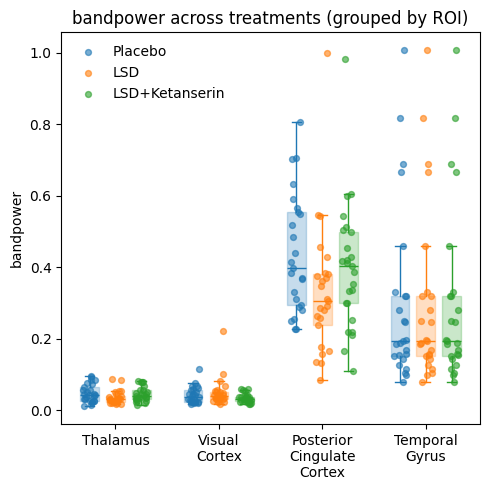

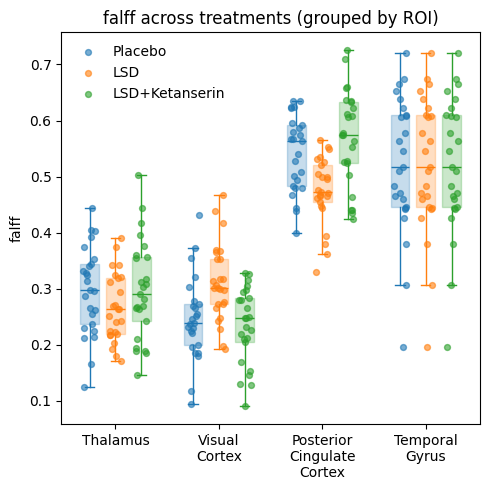

In [87]:
plot_across_treatments(features, metric="bandpower", roi_names=[part.replace('_', '\n') for part in parts])
plot_across_treatments(features, metric="falff", roi_names=[part.replace('_', '\n') for part in parts])

In [73]:
def plot_pairwise_differences(features, metric="bandpower", roi_names=None,
                              comparisons=(("Placebo", "LSD"),
                                           ("LSD", "LSD+Ketanserin"),
                                           ("Placebo", "LSD+Ketanserin")),
                              **kwargs):
    groups = {f"{B} − {A}": (np.asarray(features[B][metric]) - np.asarray(features[A][metric]))
              for A, B in comparisons}

    fig, ax = _grouped_box_jitter(
        groups,
        roi_names=roi_names,
        title=f"Within-subject Δ{metric} (grouped by ROI)",
        ylabel=f"Δ {metric}",
        **kwargs
    )
    ax.axhline(0, linewidth=1)
    plt.show()

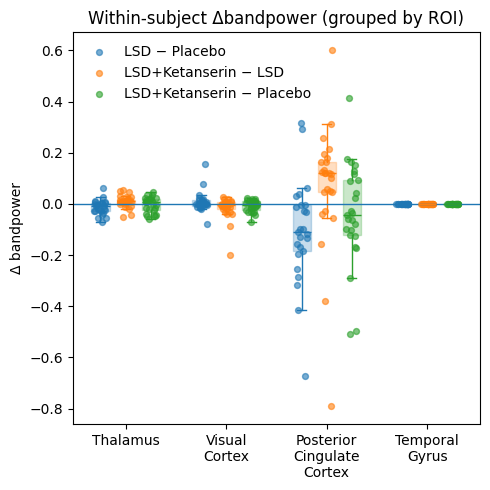

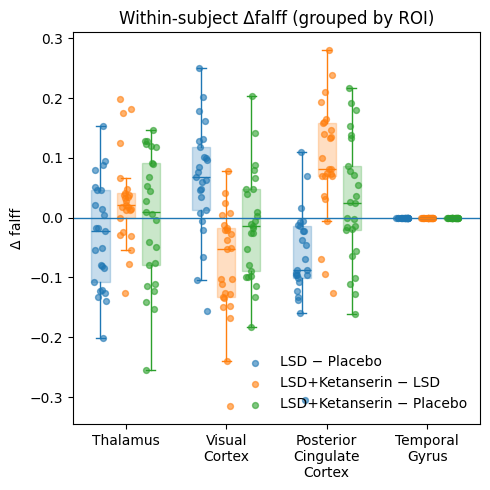

In [86]:
plot_pairwise_differences(features, metric="bandpower", roi_names= [part.replace('_', '\n') for part in parts])
plot_pairwise_differences(features, metric="falff", roi_names=[part.replace('_', '\n') for part in parts])